# Customer Churn Analytics & Retention Analysis

In [313]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [315]:
excel_file='customer_churn_data_raw.xlsx'

conn=sqlite3.connect('customer_churn.db')
excel_data=pd.ExcelFile(excel_file)

for sheet in excel_data.sheet_names:
     df=pd.read_excel(excel_file,sheet_name=sheet)
     df.to_sql(
        name=sheet,
        con=conn,
        if_exists='replace',
        index=False
      )

conn.close()
print("ALl the sheet successfully coverted into sql lite")

ALl the sheet successfully coverted into sql lite


In [316]:

conn=sqlite3.connect('customer_churn.db')

sql_query="""
SELECT name 
FROM sqlite_master
where type='table'
"""

tables=pd.read_sql(sql_query,conn)

#create datafram

for table_name in tables['name']:
    df= pd.read_sql(f"SELECT * FROM {table_name}",conn)
    globals()[f"df_{table_name}"]=df
    print(f"created datafram: df_{table_name}")


conn.close()

created datafram: df_db_customer
created datafram: df_db_subscription
created datafram: df_db_support


In [317]:
print(tables)

              name
0      db_customer
1  db_subscription
2       db_support


In [318]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [319]:
# data Cleaning

In [320]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [321]:
# a. drop columns instrest and pincode
df_db_customer.columns = df_db_customer.columns.str.strip()

In [322]:
df_db_customer.drop(columns=[ 'interests' , 'pincode'],inplace=True)

In [323]:
df_db_customer

,customerid,name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [324]:
# b. rename columns of name - customer_name
df_db_customer.rename(columns={'name' : 'customer_name'} , inplace =True)
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [325]:
# d . change datatype of DOB
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerid     21 non-null     object
 1   customer_name  21 non-null     object
 2   country        18 non-null     object
 3   state          21 non-null     object
 4   gender         21 non-null     object
 5   dob            21 non-null     object
dtypes: object(6)
memory usage: 1.1+ KB


In [326]:
# d . change datatype of DOB
(df_db_customer['dob'])=pd.to_datetime(df_db_customer['dob'])
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [327]:
# e. Data standardization - of gender columns
df_db_customer['gender']=df_db_customer['gender'].replace({'Men' : 'Male' , 'Women' : 'Female'})
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [328]:
#creating a key value pairs in the state-country
# c. fill missing value in the country

country_state_mapping = df_db_customer.dropna(subset='country').set_index('state')['country'].to_dict()
df_db_customer['country']=df_db_customer['country'].fillna(df_db_customer['state'].map(country_state_mapping))

In [329]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [330]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [331]:
date_col=['subscription_start_date' , 'renewal_date' , 'cancellation_date']    

In [332]:
df_db_subscription[date_col]=df_db_subscription[date_col].apply(pd.to_datetime)

In [333]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [334]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 560.0+ bytes


In [335]:
df_db_support.drop(columns=['col_1' , 'comment'],inplace=True)

In [336]:
df_db_support['complaint_date']=pd.to_datetime(df_db_support['complaint_date'])

In [337]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 416.0+ bytes


In [338]:
# Feature Engineering & data Analysis
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [339]:
df_db_subscription['churn_flage']=np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [340]:
# first fix support table duplicate and then merge
df=(df_db_subscription.merge(df_db_customer , on='customerid' , how='left')
                  .merge(df_db_support , on='customerid' , how='left'))

In [341]:
df.shape

(23, 20)

In [342]:
df_db_subscription.shape

(21, 12)

In [343]:
df_db_customer.shape

(21, 6)

In [344]:
df_db_support.shape

(9, 4)

In [345]:
df_db_support['complain_count']=df_db_support.groupby('customerid')['customerid'].transform('count')

In [346]:
df_db_support=df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep='last')

In [347]:
df=(df_db_subscription.merge(df_db_customer , on='customerid' , how='left')
                  .merge(df_db_support , on='customerid' , how='left'))

In [348]:
df.shape

(21, 21)

In [349]:
df.to_csv('customer_churn_data_raw.xlsx' , index=False)

In [350]:
#churn rate
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flage', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complain_count'],
      dtype='object')

In [351]:
churn_rate=df['churn_flage'].mean()*100
print("churn rate is " , round(churn_rate , 2) , '%')

churn rate is  28.57 %


In [352]:
ratention_rate=100-churn_rate
print("retention rate " , round(ratention_rate , 2) , '%')

retention rate  71.43 %


In [353]:
churn_by_plane=(df.groupby('plan_type')['churn_flage'].mean().mul(100).round(2).reset_index(name='plane_type_%'))
print(churn_by_plane)

  plan_type  plane_type_%
0     Basic         60.00
1   Premium         14.29
2  Standard         22.22


In [354]:
df.tail(5)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flage,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complain_count
16,0020-JDNXP,2022-01-19,Organic,2024-01-19,Premium,Annual,NaT,None,20.99,550,...,0,rikim,India,Meghalaya,Female,1994-08-19,NaT,NaN,NaN,NaN
17,0021-IKXGC,2021-07-07,Paid,2025-07-07,Standard,Annual,NaT,None,13.99,840,...,0,vishakha,India,Rajasthan,Female,2000-09-02,NaT,NaN,NaN,NaN
18,0022-TCJCI,2023-09-14,Refferal,2024-09-14,Basic,Monthly,2024-09-14,Forgot to cancel trial,16.99,42,...,1,raghvendra,India,Telangana,Male,1983-12-30,2024-09-14,N,90.0,2.0
19,0023-HGHWL,2020-06-23,Organic,2025-06-23,Premium,Annual,NaT,None,22.99,1955,...,0,rishabh,India,Uttar Pradesh,Male,1991-05-14,NaT,NaN,NaN,NaN
20,0023-UYUPN,2022-12-31,Paid,2025-12-31,Standard,Monthly,NaT,None,13.99,790,...,0,sudevi,India,Maharashtra,Female,1977-10-06,NaT,NaN,NaN,NaN


In [355]:
# churn by subscription type
churn_by_subscription_type=df.groupby('subscription_type')['churn_flage'].mean().mul(100)
print(churn_by_subscription_type)

subscription_type
Organic      0.000000
Paid        16.666667
Refferal    83.333333
Name: churn_flage, dtype: float64


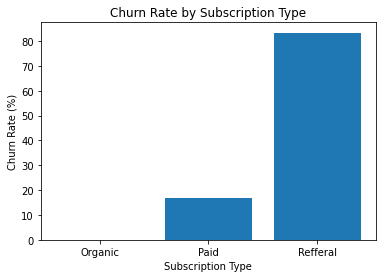

In [356]:
plt.bar(
    churn_by_subscription_type.index,
    churn_by_subscription_type.values
)

plt.xlabel("Subscription Type")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Subscription Type")

plt.show()

In [357]:
# churn by state type
churn_by_state=df.groupby('state')['churn_flage'].mean().mul(100)

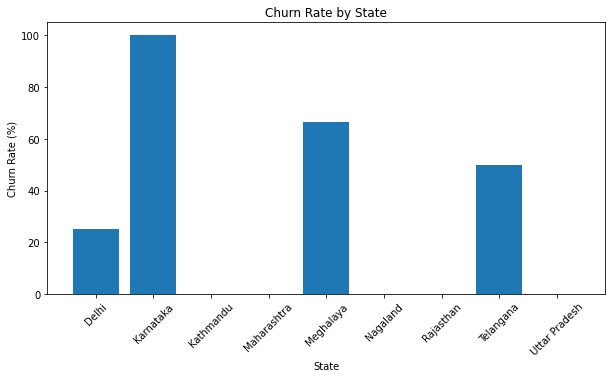

In [358]:
plt.figure(figsize=(10, 5))

plt.bar(
    churn_by_state.index,
    churn_by_state.values
)

plt.xlabel("State")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by State")

plt.xticks(rotation=45)

plt.show()

In [359]:
ARPU=df['monthly_charges'].mean()
print("ARPU" , round(ARPU,2))

ARPU 18.85


In [360]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flage', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complain_count'],
      dtype='object')

In [361]:
# avg customer tenure
#count of the days user has used our service : canceleetion date else current date
today = pd.Timestamp.today()


In [362]:
# avg customer tenure
#count of the days user has used our service : canceletion date else current date

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),
   (df['cancellation_date'] - df['subscription_start_date']).dt.days,
   (today - df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()
print("Avg tenure days" , round(avg_tenure),0)

Avg tenure days 1553 0


In [363]:
# revenue ate risk
revenue_at_risk = df.loc[df['churn_flage'] ==1 ,'monthly_charges'].sum()
print('revenue at risk (Rs . Lakhs) =' , revenue_at_risk)

revenue at risk (Rs . Lakhs) = 73.94


In [364]:
# Escalaltioln rate 
escalation_rate =(df['escalations'] =='Y').mean()*100
print("escalation rate" , round(escalation_rate,2) ,"%")

escalation rate 19.05 %


In [365]:
# Avg complaint per user
avg_complaint = df['complain_count'].count() / df['customerid'].nunique()
print("Avg complain per user" , round(avg_complaint,2) )

Avg complain per user 0.33


In [366]:
# Correlation between escalation and Churn
df['escalations'] =np.where(df['escalations'] =='Y' ,1 , 0)  #Encoding from str to int
df_corr = df[['escalations' , 'churn_flage']].dropna()

In [367]:
corelation = df['escalations'].corr(df_corr['churn_flage'])

print('Corelation between Escalation and churn is' , round(corelation,2))

Corelation between Escalation and churn is 0.77


In [368]:
# Crerating a columns using existing columns
conditions = [
       (df['churn_score'] <50),
       (df['churn_score'] >= 50) & (df['churn_score'] <70 ),
       (df['churn_score'] >= 70)
]

choice =['Low' ,'Med' ,'High']
df['churn_risk'] = np.select(conditions,choice)

In [369]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flage', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complain_count',
       'tenure_days', 'churn_risk'],
      dtype='object')

# Data Visulization

In [370]:
df_vis = df.copy()

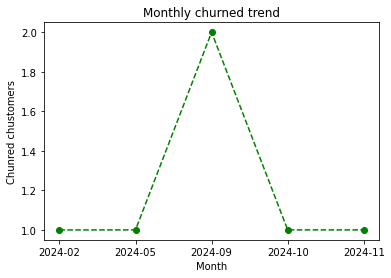

In [371]:
# Monthly Churn Trend
import matplotlib.pyplot as plt
df_vis['cancellation_month']=df_vis['cancellation_date'].dt.to_period('M')

churn_trend=df_vis[df_vis['churn_flage']==1].groupby('cancellation_month').size()
plt.plot(churn_trend.index.astype(str) , churn_trend.values , color = 'green' , marker='o' ,linestyle ='dashed')
plt.title('Monthly churned trend')
plt.xlabel('Month')
plt.ylabel('Chunred chustomers')
plt.show()

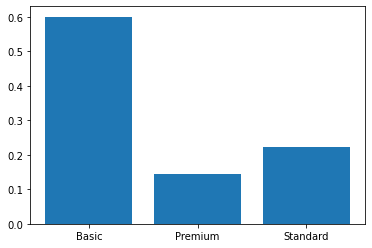

In [372]:
# churn by plane type
churn_plane=df_vis.groupby('plan_type')['churn_flage'].mean()

plt.bar(churn_plane.index , churn_plane.values)
plt.show()

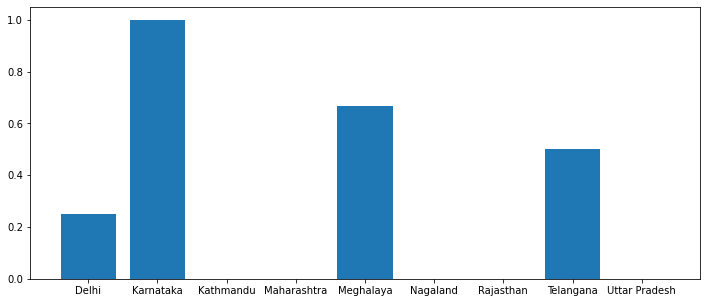

In [373]:
# churn by states
churn_state = df_vis.groupby('state')['churn_flage'].mean()
plt.figure(figsize=(12,5))
plt.bar(churn_state.index , churn_state.values)
plt.show()

In [374]:
# Visulization using seaborn

In [375]:
# Encoding from str to numeric
# Incorrect method of encoding from str to int based on the priority
df_encode = df_vis[['plan_type' , 'contract_type' , 'churn_flage' , 'churn_score' , 'churn_risk' , 'escalations']]
df_category = ['plan_type' ,'contract_type' ,'churn_risk']

for col in df_category:
    df_encode[col] = df_encode[col].astype('category').cat.codes

print(df_encode.head())
print(df_encode.dtypes)

   plan_type  contract_type  churn_flage  churn_score  churn_risk  escalations
0          2              0            0           12           1            0
1          1              0            1           91           0            1
2          0              1            0           34           1            0
3          1              0            0            8           1            0
4          2              1            1           88           0            1
plan_type         int8
contract_type     int8
churn_flage      int64
churn_score      int64
churn_risk        int8
escalations      int64
dtype: object


/tmp/ipykernel_166/449829713.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_encode[col] = df_encode[col].astype('category').cat.codes
/tmp/ipykernel_166/449829713.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_encode[col] = df_encode[col].astype('category').cat.codes
/tmp/ipykernel_166/449829713.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:

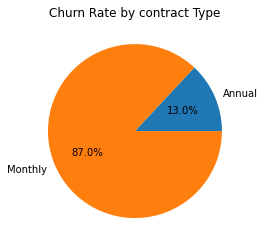

In [376]:
# Churn Rate by Contrcat Type
plt.pie(
    churn_by_contract.values,
    labels=churn_by_contract.index,
    autopct='%.1f%%'
)
plt.title("Churn Rate by contract Type")
plt.show()


In [377]:
df_vis['churn_risk'].unique()

array(['Low', 'High', 'Med'], dtype=object)

In [378]:
# correct methhod of doing encoding from based on the priority
df_encode = df_vis[['plan_type' , 'contract_type' , 'churn_flage' , 'churn_score' , 'churn_risk' , 'escalations']]

mapping_pair ={
    'plan_type' : ['Basic','Standard','Premium'],
    'contract_type':['Monthly','Annual'],
    'churn_risk' : ['Low','Med' ,'High']
}

for col,order in mapping_pair.items():
    df_encode[col]=pd.Categorical(df_encode[col].astype('category') , categories = order , ordered=True).codes
    

/tmp/ipykernel_166/1544810885.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_encode[col]=pd.Categorical(df_encode[col].astype('category') , categories = order , ordered=True).codes
/tmp/ipykernel_166/1544810885.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_encode[col]=pd.Categorical(df_encode[col].astype('category') , categories = order , ordered=True).codes
/tmp/ipykernel_166/1544810885.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

In [379]:
df_encode.head()

,plan_type,contract_type,churn_flage,churn_score,churn_risk,escalations
0,1,1,0,12,0,0
1,2,1,1,91,2,1
2,0,0,0,34,0,0
3,2,1,0,8,0,0
4,1,0,1,88,2,1


<AxesSubplot:>

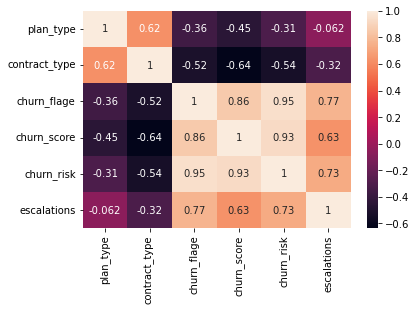

In [380]:
import seaborn as sns
sns.heatmap(df_encode.corr() , annot = True)

In [381]:
# pivot table

In [382]:
pd.pivot_table(
    df_vis,
    index ='plan_type',
    values=['monthly_charges' ,'customerid','churn_flage'],
    aggfunc={
         'monthly_charges' : 'sum',
         'customerid'      : 'count',
         'churn_flage' : 'mean'
    }
)

,churn_flage,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [383]:
df_vis.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flage', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complain_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [384]:
# Working with sql in python or pandas

In [387]:
# create database
conn.execute("DROP TABLE IF EXISTS user")

conn.execute("""
CREATE TABLE user(
    first_name TEXT,
    country TEXT,
    budget INTEGER
)
""")

conn.commit()

ProgrammingError: Cannot operate on a closed database.

In [ ]:
# insert data
cursor = conn.cursor()

# write the query to insert records into the sql table
cursor.execute(
    """
    INSERT INTO user VALUES
    ('Ashutosh','INDIA','5000'),
    ('prashant' , 'india' ,'20000'),
    ('sameer' ,' UAE','50000')
    """
)
# commit and save
conn.commit()
print('Data insert successfully')

In [ ]:
# check the inserted records
conn=sqlite3.connect('tes_database.sqlite')
query="""
SELECT * FROM user
"""
df_result = pd.read_sql(query,conn)
df_result.head()

In [ ]:
# aggregation 
query = """
      SELECT country , sum(budget) as total_budget
      FROM user
      GROUP BY country
"""

df_agg =pd.read_sql(query,conn)
df_agg

In [388]:
# closing connect
conn.close()